# PIZZA SALES ANALYSIS #

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\91911\OneDrive\Data\Pizza_Sales.csv')

In [3]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
print("No of rows n columns",df.shape)

No of rows n columns (48620, 12)


In [5]:
print("No of rows ",df.shape[0])

No of rows  48620


In [6]:
print("No of columns",df.shape[1])

No of columns 12


In [7]:
df.columns

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [8]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


## KPI'S ##

In [9]:
#Total revenue
total_revenue=df['total_price'].sum()
total_pizza_sold=df['quantity'].sum()
total_orders=df['order_id'].nunique()
avg_order_value=total_pizza_sold/total_orders
print(f"total_revenue:${total_revenue:.2f}")
print(f"total_pizza_sold:${total_pizza_sold:.2f}")
print(f"total_orders:${total_orders}")
print(f"avg_order_value:{avg_order_value:.0f}")

total_revenue:$817860.05
total_pizza_sold:$49574.00
total_orders:$21350
avg_order_value:2


## Chart Requirments ##

## Daily Trend for total orders ##

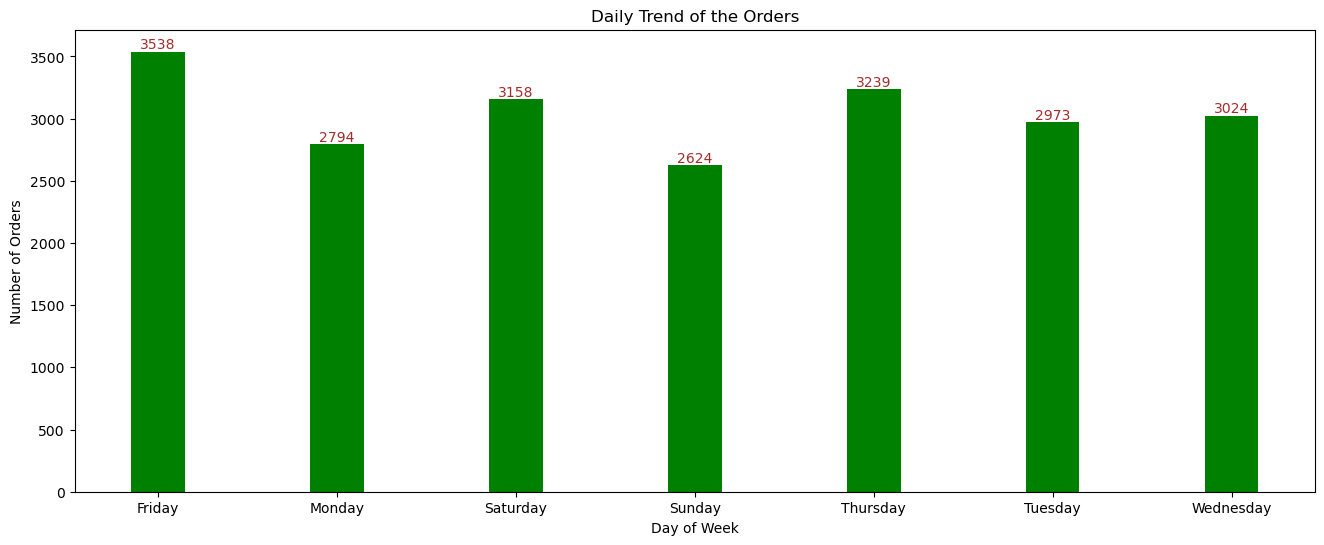

In [29]:
df['order_date']=pd.to_datetime(df['order_date'],dayfirst=True)
df['Day_Name']=df['order_date'].dt.day_name()
week_order=[ 'Monday', 'Tuesday', 'Wednesday',
  'Thursday', 'Friday', 'Saturday', 'Sunday']
Daily_orders=df.groupby('Day_Name')['order_id'].nunique()

plt.figure(figsize=(16,6))
plt.bar(Daily_orders.index,Daily_orders.values,color='green',width=0.3)
plt.title('Daily Trend of the Orders')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')

for i,val in zip(Daily_orders.index,Daily_orders.values):
 plt.text(i,val,val,ha="center",color='brown',fontsize=10,va='bottom')

plt.show()

C:\Users\91911\AppData\Local\Temp\ipykernel_36760\2863854143.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hours']=pd.to_datetime(df['order_time'])


[]

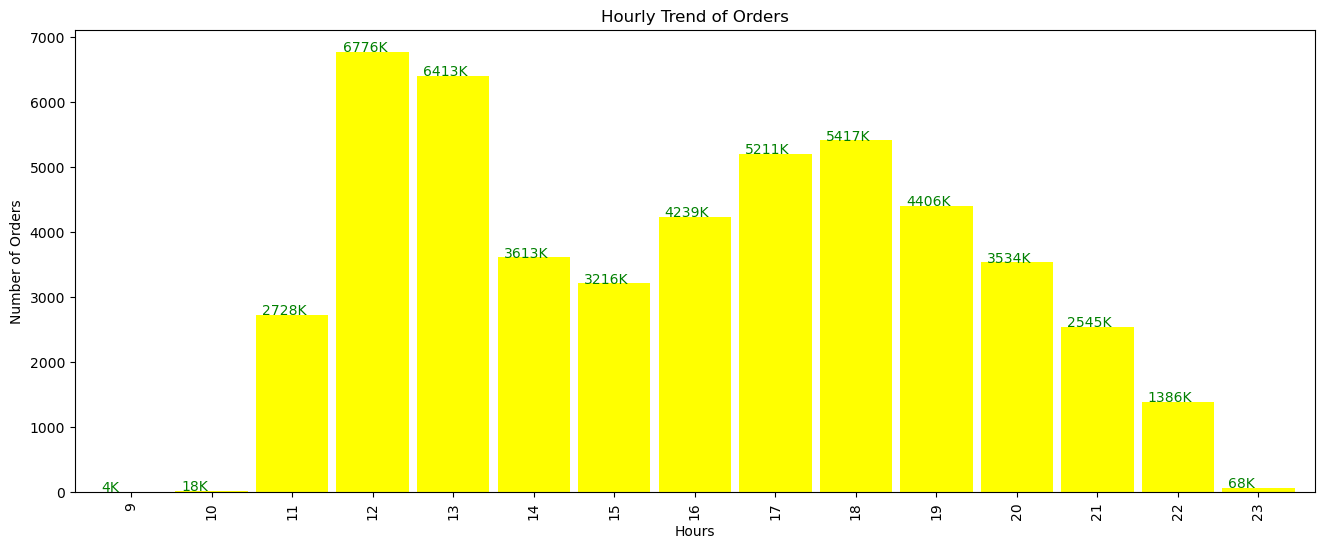

In [32]:
df['Hours']=pd.to_datetime(df['order_time'])
df['Hours']=df['Hours'].dt.hour
plt.figure(figsize=(16,6))
Hourlywise_pizzas_sold=df.groupby('Hours')['quantity'].sum()
ax=Hourlywise_pizzas_sold.plot(kind='bar',color='yellow',width=0.9)
plt.title('Hourly Trend of Orders')
plt.xlabel('Hours')
plt.ylabel('Number of Orders')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}K',
        (p.get_x()+p.get_width()/12,p.get_height()),
        color="green"
    )
plt.plot()

### total orders by month ###

## % of Sales by Pizza Category ##

In [ ]:
df.head(2)

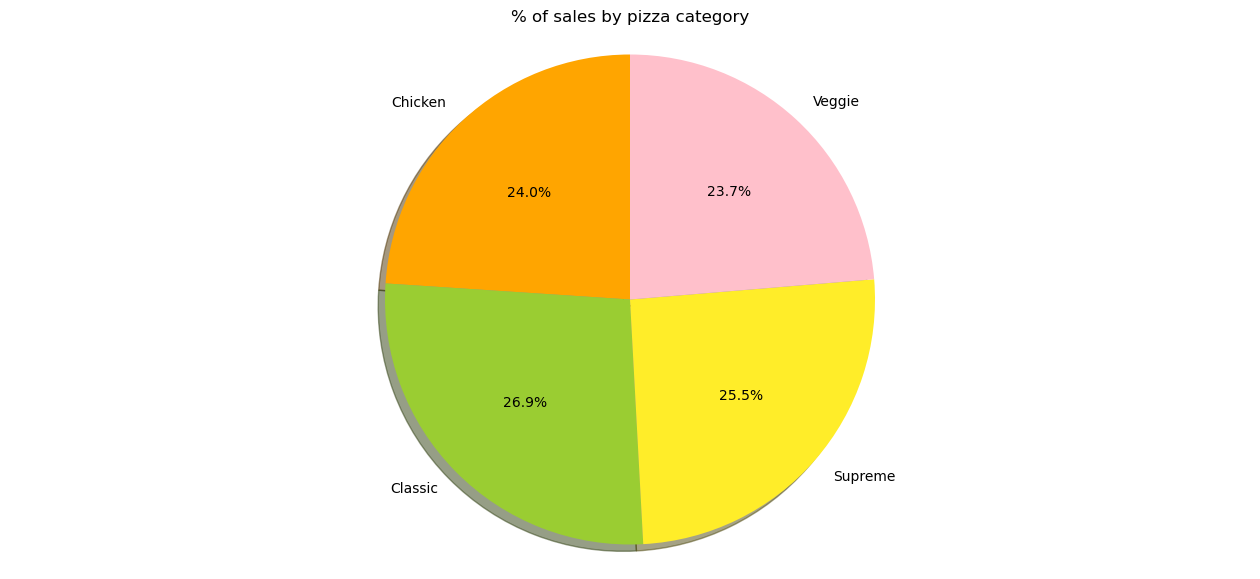

In [35]:
Sales_by_PizzaCategory = df.groupby('pizza_category')['total_price'].sum()
percentage = Sales_by_PizzaCategory / Sales_by_PizzaCategory.sum() * 100

plt.figure(figsize=(16, 7))
plt.pie(Sales_by_PizzaCategory,labels=Sales_by_PizzaCategory.index,autopct='%1.1f%%',startangle=90,
        colors=['orange', '#9acd32', '#ffed29',"pink"],shadow=True)
plt.title('% of sales by pizza category')

plt.axis('equal')
plt.show()

### % sales by pizza size ###

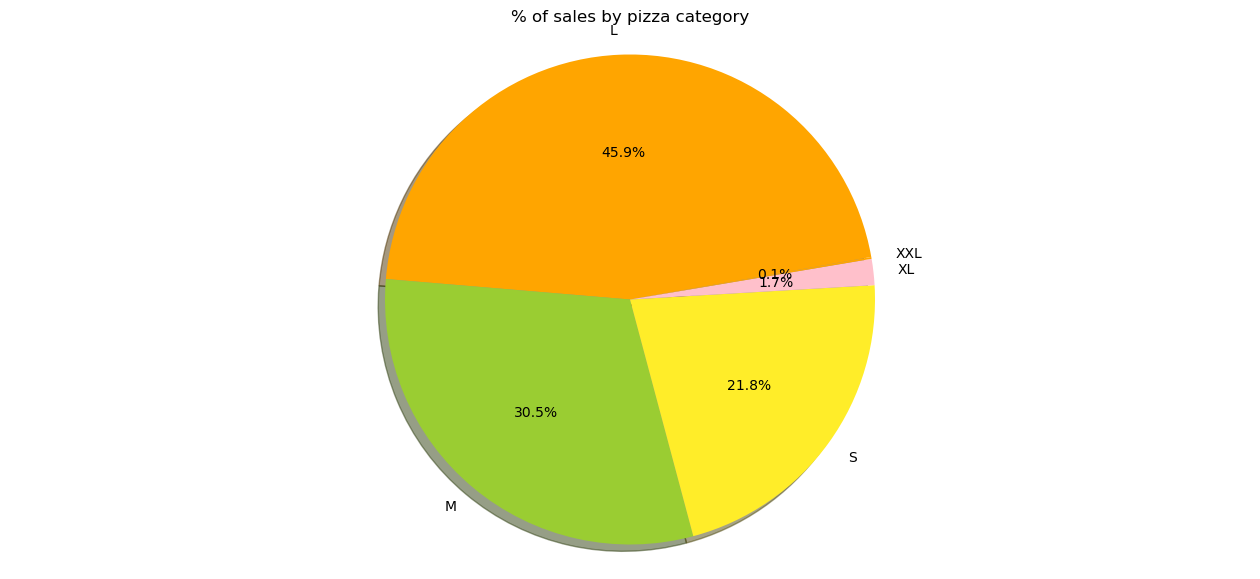

In [39]:
Sales_by_Pizza_size = df.groupby('pizza_size')['total_price'].sum()
percentage = Sales_by_Pizza_size / Sales_by_Pizza_size.sum() * 100

plt.figure(figsize=(16, 7))
plt.pie(Sales_by_Pizza_size,labels=Sales_by_Pizza_size.index,autopct='%1.1f%%',startangle=10,
        colors=['orange', '#9acd32', '#ffed29',"pink"],shadow=True)
plt.title('% of sales by pizza category')

plt.axis('equal')  # Makes the pie chart circular
plt.show()

### Total Pizzas Sold by Pizza Category ###

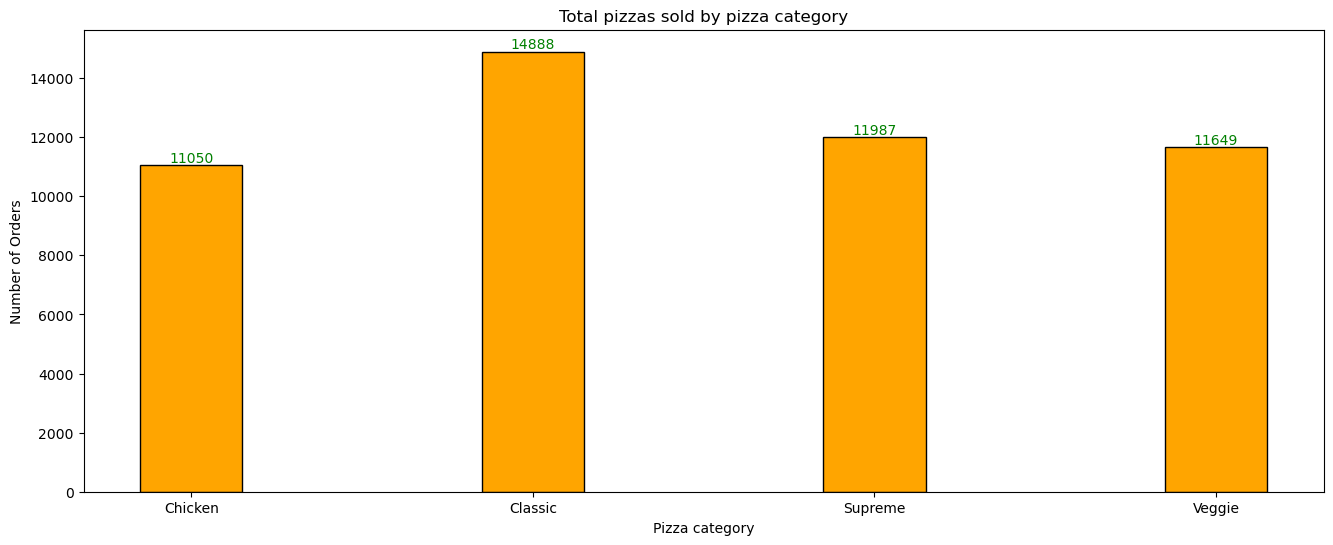

In [52]:
Pizzas_soldby_Pizza_Category=df.groupby('pizza_category')['quantity'].sum()
plt.figure(figsize=(16,6))
plt.bar(Pizzas_soldby_Pizza_Category.index,Pizzas_soldby_Pizza_Category.values,color='orange',edgecolor='black',width=0.3)
plt.title('Total pizzas sold by pizza category')
plt.xlabel('Pizza category')
plt.ylabel('Number of Orders')

for i,val in zip(Pizzas_soldby_Pizza_Category.index,Pizzas_soldby_Pizza_Category.values):
 plt.text(i,val,val,ha="center",color='green',fontsize=10,va='bottom')
plt.show()

### Top 5 Pizzas by Quantity ###

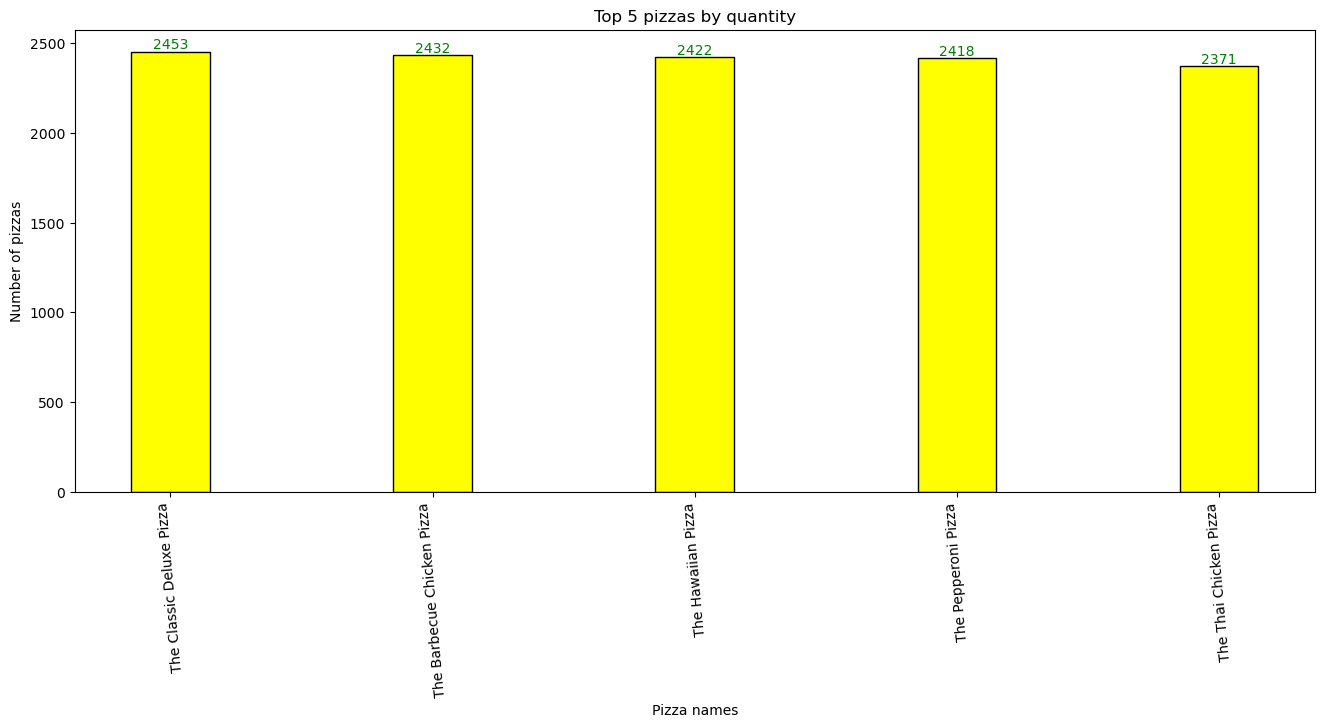

In [61]:
pizza_name=df.groupby('pizza_name')['quantity'].sum()
top5=pizza_name.sort_values(ascending=False).head(5)
plt.figure(figsize=(16,6))
plt.bar(top5.index,top5.values,color='yellow',edgecolor='black',width=0.3)
plt.title('Top 5 pizzas by quantity')
plt.xlabel('Pizza names')
plt.ylabel('Number of pizzas')

for i,val in zip(top5.index,top5.values):
 plt.text(i,val,val,ha="center",color='green',fontsize=10,va='bottom')
plt.xticks(rotation=95)
plt.show()

### Bottom 5 Pizzas by Quantity ###

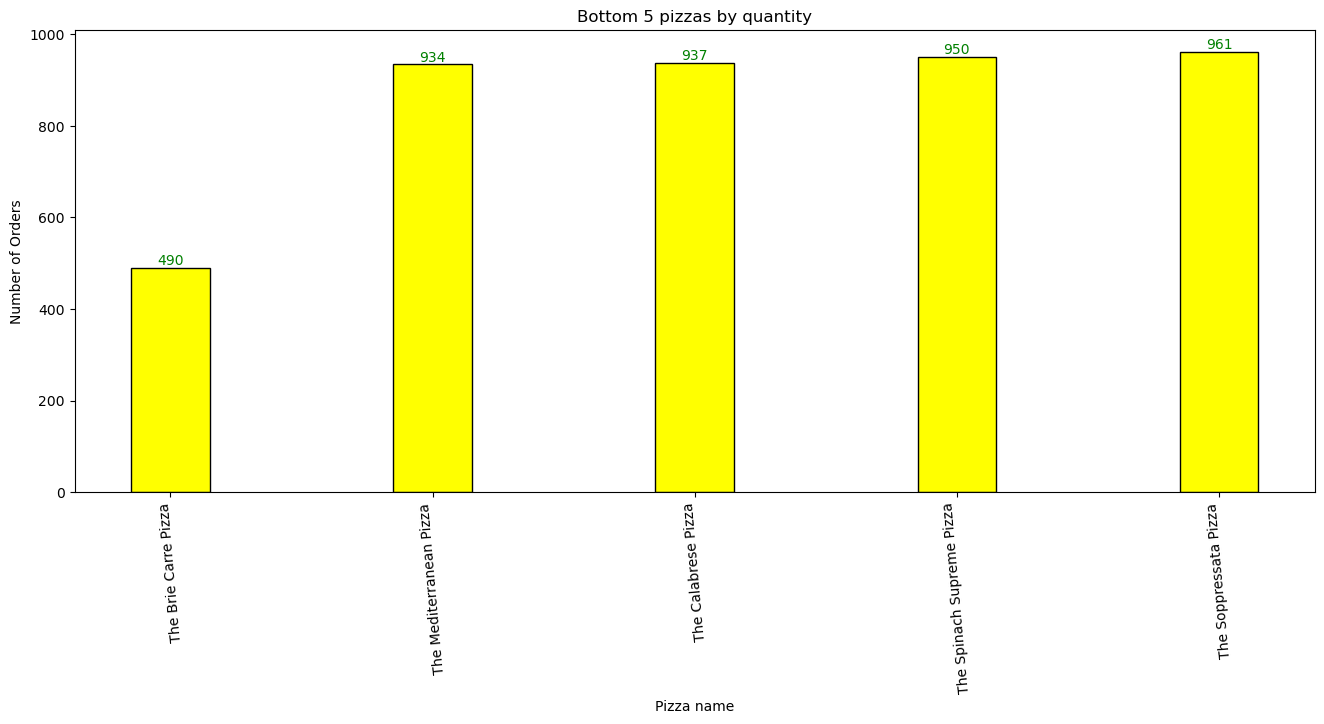

In [58]:
pizza_name=df.groupby('pizza_name')['quantity'].sum()
bottom5=pizza_name.sort_values(ascending=True).head(5)
plt.figure(figsize=(16,6))
plt.bar(bottom5.index,bottom5.values,color='yellow',edgecolor='black',width=0.3)
plt.xticks(rotation=95)

plt.title('Bottom 5 pizzas by quantity')
plt.xlabel('Pizza name')
plt.ylabel('Number of Orders')

for i,val in zip(bottom5.index,bottom5.values):
 plt.text(i,val,val,ha="center",color='green',fontsize=10,va='bottom')
plt.show()